# Spatial Context Benchmarking

This notebook measures how much spatial context OmniCloudMask needs to produce accurate cloud masks. The question: if you only need to classify a small area (32×32 pixels), does providing surrounding context improve accuracy?

**Method:**
1. For each scene in the CloudSEN12 High test set, extract center patches of increasing size (32–509 px)
2. Run OmniCloudMask on each patch
3. Evaluate only the center 32×32 pixels against the ground truth label
4. Repeat at different spatial resolutions (10m, 20m, 30m) by downsampling the native 10m imagery

This reveals how much extra context is needed at each resolution and where the accuracy gain plateaus.

In [1]:
import json
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch
from scipy.ndimage import zoom
from sklearn.metrics import balanced_accuracy_score, f1_score
from tqdm.auto import tqdm

import omnicloudmask
from omnicloudmask import predict_from_array

## 1. Configuration

Set the dataset path, patch sizes to test, and resolution factors. The evaluation size is fixed at 32×32 pixels — this is the area we actually care about classifying. Larger patch sizes provide more surrounding context for the model.

In [2]:
DATASET_DIR = Path("/media/nick/4TB Working 7/Datasets/OCM datasets v3/CloudSEN12 test")
EVAL_SIZE = 32  # Center pixels to evaluate
PATCH_SIZES = [32, 48, 64, 96, 128, 192, 256, 320, 384, 448, 509]
RESOLUTION_FACTORS = {"10m": 1, "20m": 2, "30m": 3, "40m": 4, "50m": 5}
CLASS_NAMES = {0: "Clear", 1: "Thick Cloud", 2: "Thin Cloud", 3: "Cloud Shadow"}
N_WORKERS = 4  # Threads for concurrent predict_from_array calls

# Discover scenes: pair each L2A image with its label
l2a_files = sorted(DATASET_DIR.glob("*_l2a.tif"))
scenes = []
for img_path in l2a_files:
    label_path = img_path.parent / img_path.name.replace("_image_l2a", "_label")
    if label_path.exists():
        scenes.append((img_path, label_path))

print(f"Found {len(scenes)} scenes")
print(f"Patch sizes: {PATCH_SIZES}")
print(f"Eval size: {EVAL_SIZE}\u00d7{EVAL_SIZE} pixels")
print(f"Resolutions: {list(RESOLUTION_FACTORS.keys())}")
print(f"Workers: {N_WORKERS}")

Found 975 scenes
Patch sizes: [32, 48, 64, 96, 128, 192, 256, 320, 384, 448, 509]
Eval size: 32×32 pixels
Resolutions: ['10m', '20m', '30m', '40m', '50m']
Workers: 4


## 2. Helper functions

- `center_crop` extracts the center region from an array
- `downsample_image` simulates coarser resolutions
- `compute_metrics` calculates BOA and per-class Dice scores

In [3]:
def center_crop(arr: np.ndarray, crop_size: int) -> np.ndarray:
    """Extract center crop from array of shape (C, H, W) or (H, W)."""
    if arr.ndim == 3:
        _, h, w = arr.shape
        y0 = (h - crop_size) // 2
        x0 = (w - crop_size) // 2
        return arr[:, y0 : y0 + crop_size, x0 : x0 + crop_size]
    h, w = arr.shape
    y0 = (h - crop_size) // 2
    x0 = (w - crop_size) // 2
    return arr[y0 : y0 + crop_size, x0 : x0 + crop_size]


def downsample_image(arr: np.ndarray, factor: int) -> np.ndarray:
    """Downsample (C, H, W) array by integer factor using bilinear interpolation."""
    return zoom(arr, (1, 1 / factor, 1 / factor), order=1).astype(arr.dtype)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Compute BOA (balanced overall accuracy) and per-class Dice scores."""
    return {
        "boa": float(balanced_accuracy_score(y_true, y_pred)),
        "dice_per_class": {
            CLASS_NAMES[c]: float(v)
            for c, v in enumerate(
                f1_score(
                    y_true,
                    y_pred,
                    average=None,
                    labels=[0, 1, 2, 3],
                    zero_division=0,
                )
            )
        },
    }

## 3. Run experiment

For each resolution:
1. Pre-load all images and labels into memory (and downsample if needed)
2. For each patch size, run threaded `predict_from_array` calls across all scenes
3. Evaluate the center 32×32 pixels of each prediction

Pre-loading avoids re-reading images from disk for every patch size. Threading overlaps I/O and CPU preprocessing with GPU inference.

In [4]:
def predict_scene(
    img: np.ndarray,
    label_10m: np.ndarray,
    patch_size: int,
    eval_size: int,
    factor: int,
    n_rotations: int = 4,
) -> tuple[np.ndarray, np.ndarray]:
    """Crop, predict, and evaluate one scene with rotation TTA. Thread-safe.

    For each rotation, predict on the rotated image and rotate the label
    by the same amount so the comparison stays in the rotated frame.
    This produces independent per-pixel samples across rotations for
    robust metrics and smoother spatial heatmaps.

    Predictions at coarser resolutions are upsampled back to 10m so all
    resolutions are evaluated against the same 10m ground truth.
    """
    img_patch = center_crop(img, patch_size)
    label_center = center_crop(label_10m, eval_size)

    preds = []
    labels = []
    for k in range(n_rotations):
        img_rot = np.ascontiguousarray(np.rot90(img_patch, k=k, axes=(-2, -1)))

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            pred = predict_from_array(
                img_rot,
                patch_size=patch_size,
                patch_overlap=0,
                inference_dtype=torch.float16,
            )

        if factor > 1:
            # Upsample prediction back to 10m for fair comparison
            pred_10m = zoom(pred, (1, factor, factor), order=0)
            pred_center = center_crop(pred_10m[0], eval_size)
        else:
            pred_center = center_crop(pred[0], eval_size)

        # Rotate label to match, so comparison stays in the rotated frame
        label_rot = np.rot90(label_center, k=k, axes=(-2, -1))

        preds.append(pred_center)
        labels.append(label_rot)

    return np.stack(preds), np.stack(labels)


results = {}
pixel_accuracy_10m: dict[
    int, np.ndarray
] = {}  # patch_size -> (eval_size, eval_size) mean correctness

for res_name, factor in RESOLUTION_FACTORS.items():
    print(f"\n{'=' * 60}")
    print(f"Resolution: {res_name} (downsample factor: {factor})")
    print(f"{'=' * 60}")

    # Pre-load all images (downsampled) and 10m labels into memory
    images: list[np.ndarray] = []
    labels_10m: list[np.ndarray] = []
    for img_path, label_path in tqdm(scenes, desc=f"Loading {res_name}"):
        with rasterio.open(img_path) as src:
            img = src.read()
        with rasterio.open(label_path) as src:
            label = src.read(1)
        labels_10m.append(label)
        if factor > 1:
            img = downsample_image(img, factor)
        images.append(img)

    effective_size = min(images[0].shape[1], images[0].shape[2])
    print(
        f"Loaded {len(images)} scenes, images at {effective_size}\u00d7{effective_size} px"
    )

    # Include the full downsampled image size so all resolutions
    # cover their maximum available ground distance
    patch_sizes = sorted(set(PATCH_SIZES + [effective_size]))

    # Evaluate each patch size with threaded predictions
    res_results = {}
    for patch_size in patch_sizes:
        if patch_size > effective_size:
            continue

        all_preds: list[np.ndarray] = []
        all_labels: list[np.ndarray] = []

        with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
            futures = {
                pool.submit(
                    predict_scene,
                    images[i],
                    labels_10m[i],
                    patch_size,
                    EVAL_SIZE,
                    factor,
                ): i
                for i in range(len(images))
            }
            for future in tqdm(
                as_completed(futures),
                total=len(futures),
                desc=f"{res_name} {patch_size}px",
                leave=False,
            ):
                preds_stack, labels_stack = future.result()
                all_preds.append(preds_stack.ravel())
                all_labels.append(labels_stack.ravel())
                if factor == 1:
                    # Accumulate correctness across all rotations for smoother heatmap
                    correct = (
                        (preds_stack == labels_stack).astype(np.float32).sum(axis=0)
                    )
                    if patch_size in pixel_accuracy_10m:
                        pixel_accuracy_10m[patch_size] += correct
                    else:
                        pixel_accuracy_10m[patch_size] = correct.copy()

        y_pred = np.concatenate(all_preds)
        y_true = np.concatenate(all_labels)
        metrics = compute_metrics(y_true, y_pred)
        res_results[patch_size] = metrics
        if factor == 1 and patch_size in pixel_accuracy_10m:
            # Normalise: each scene contributes n_rotations samples per pixel
            pixel_accuracy_10m[patch_size] /= len(all_preds) * 4
        ctx_px = (patch_size - EVAL_SIZE) // 2
        print(f"  {patch_size:>4}px  ctx={ctx_px:>4}px  boa={metrics['boa']:.4f}")

    results[res_name] = res_results
    del images, labels_10m  # free memory before next resolution


Resolution: 10m (downsample factor: 1)


Loading 10m:   0%|          | 0/975 [00:00<?, ?it/s]

Loaded 975 scenes, images at 509×509 px


10m 32px:   0%|          | 0/975 [00:00<?, ?it/s]

/home/nick/Documents/Work code/OmniCloudMask/omnicloudmask/cloud_mask.py:274: UserWarning: Input width or height is less than 50 pixels, found shape (3, 32, 32). Small image may not provide adequate spatial context for the model.
  patch_overlap, patch_size = check_patch_size(


...

    64px  ctx=  16px  boa=0.7175


50m 96px:   0%|          | 0/975 [00:00<?, ?it/s]

    96px  ctx=  32px  boa=0.7513


50m 102px:   0%|          | 0/975 [00:00<?, ?it/s]

   102px  ctx=  35px  boa=0.7596


## 4. Visualise

Three plots:
1. **BOA** vs patch size (pixels) for each resolution
2. **BOA** vs patch edge length (metres) — lets users read off how large their input patch should be regardless of sensor
3. **Per-class Dice** vs patch size at 10m resolution

Written: ../docs/_static/spatial_context.png


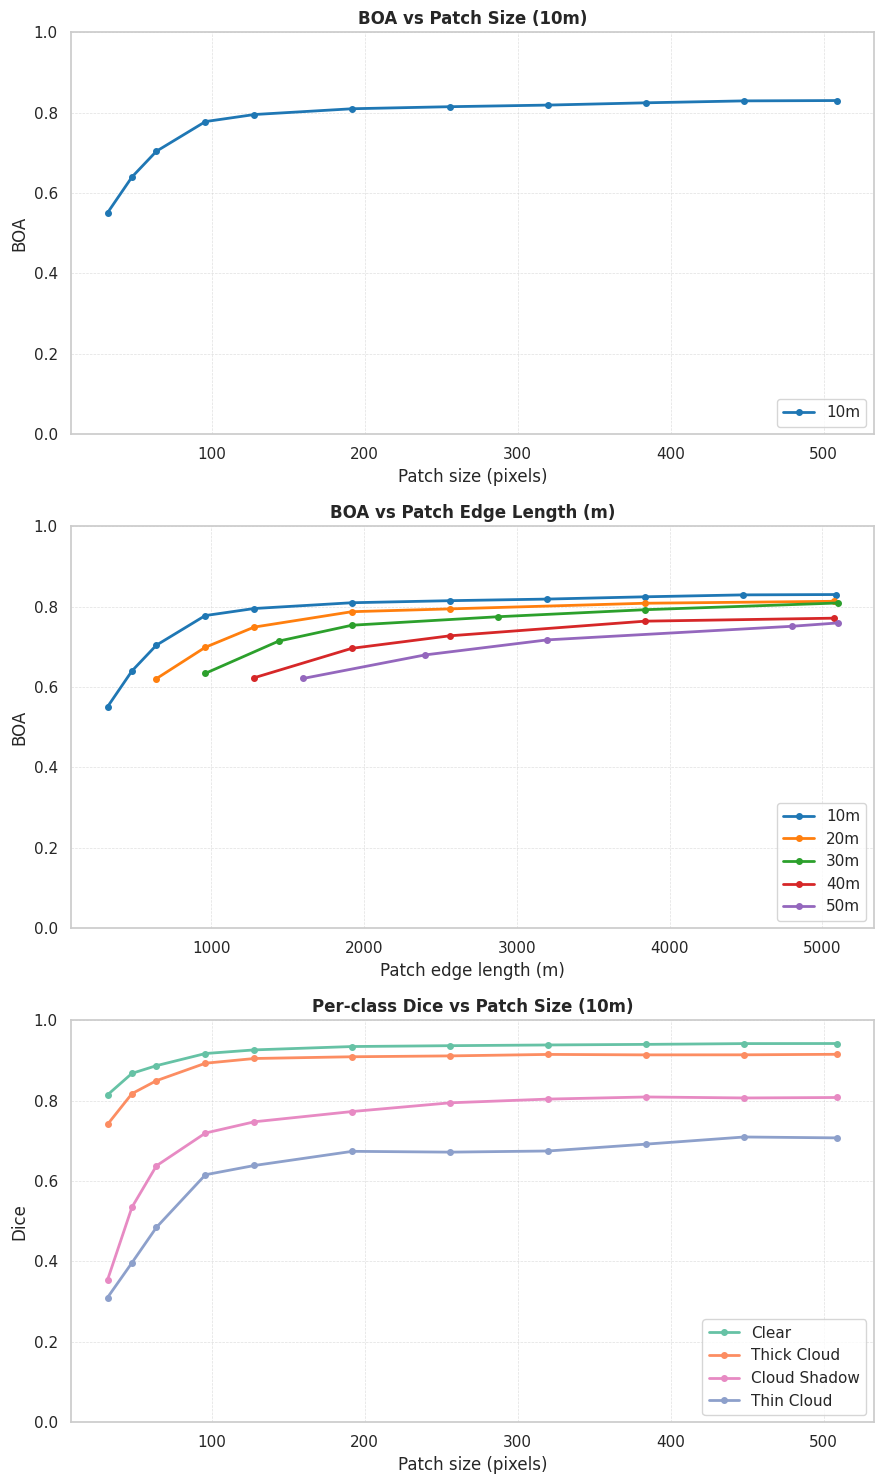

In [5]:
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(3, 1, figsize=(9, 15))

resolution_palette = sns.color_palette("tab10", len(results))

# Plot 1: BOA vs pixels (10m only)
ax = axes[0]
res_10m = results[list(results.keys())[0]]
sizes = sorted(res_10m.keys())
boa = [res_10m[s]["boa"] for s in sizes]
ax.plot(sizes, boa, "o-", color=resolution_palette[0], lw=2, label="10m", markersize=4)
ax.set_xlabel("Patch size (pixels)")
ax.set_ylabel("BOA")
ax.set_title("BOA vs Patch Size (10m)", fontweight="bold")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.6)
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# Plot 2: BOA vs patch edge length (all resolutions)
ax = axes[1]
for i, (res_name, res_results) in enumerate(results.items()):
    sizes = sorted(res_results.keys())
    base_res = int(res_name.replace(" m", "").replace("m", ""))
    edge_m = [s * base_res for s in sizes]
    boa = [res_results[s]["boa"] for s in sizes]
    ax.plot(
        edge_m,
        boa,
        "o-",
        color=resolution_palette[i],
        lw=2,
        label=res_name,
        markersize=4,
    )
ax.set_xlabel("Patch edge length (m)")
ax.set_ylabel("BOA")
ax.set_title("BOA vs Patch Edge Length (m)", fontweight="bold")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.6)
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# Plot 3: Per-class Dice at 10m (different palette, legend ordered by score)
ax = axes[2]
class_palette = sns.color_palette("Set2", len(CLASS_NAMES))
sizes = sorted(res_10m.keys())
legend_order = [0, 1, 3, 2]  # Clear, Thick Cloud, Cloud Shadow, Thin Cloud
class_list = list(CLASS_NAMES.values())
for j in legend_order:
    class_name = class_list[j]
    dice_vals = [res_10m[s]["dice_per_class"][class_name] for s in sizes]
    ax.plot(
        sizes,
        dice_vals,
        "o-",
        color=class_palette[j],
        lw=2,
        label=class_name,
        markersize=4,
    )
ax.set_xlabel("Patch size (pixels)")
ax.set_ylabel("Dice")
ax.set_title("Per-class Dice vs Patch Size (10m)", fontweight="bold")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.6)
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
docs_plot = Path("..") / "docs" / "_static" / "spatial_context.png"
docs_plot.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(docs_plot, dpi=150, bbox_inches="tight")
print(f"Written: {docs_plot}")

plt.show()

sns.reset_defaults()

## 5. Spatial distribution of errors

For each patch size at 10m, show the mean accuracy at each pixel of the 32×32 evaluation window, averaged across all scenes. This reveals whether errors cluster near the edges (where the model has seen less context on one side) or are spread evenly.

Written: ../docs/_static/spatial_context_heatmap.png


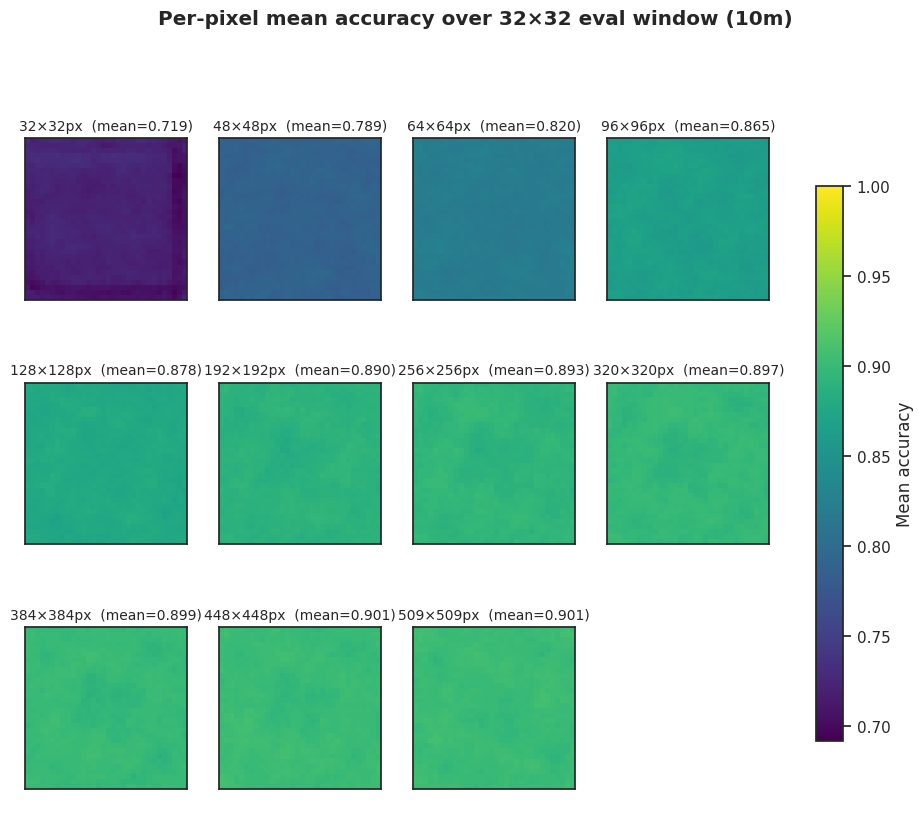

In [6]:
import seaborn as sns

sns.set_theme(style="white", context="notebook")

sizes = sorted(pixel_accuracy_10m.keys())
n = len(sizes)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3), squeeze=False)

# Shared colour scale so heatmaps are visually comparable
vmin = min(acc.min() for acc in pixel_accuracy_10m.values())
vmax = 1.0

for i, ps in enumerate(sizes):
    ax = axes[i // ncols, i % ncols]
    acc = pixel_accuracy_10m[ps]
    im = ax.imshow(acc, cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_title(f"{ps}×{ps}px  (mean={acc.mean():.3f})", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide any unused axes
for j in range(n, nrows * ncols):
    axes[j // ncols, j % ncols].axis("off")

fig.suptitle(
    "Per-pixel mean accuracy over 32×32 eval window (10m)",
    fontweight="bold",
    y=1.0,
)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="Mean accuracy")

out_path = Path("..") / "docs" / "_static" / "spatial_context_heatmap.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Written: {out_path}")
plt.show()

sns.reset_defaults()

## 5. Export results

Save all metrics to JSON for use in documentation. Each row includes the patch size, resolution, context margin in pixels and metres, and all computed metrics.

In [7]:
export: dict = {
    "fingerprint": {
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "omnicloudmask_version": omnicloudmask.__version__,
        "pytorch_version": torch.__version__,
        "dataset": "CloudSEN12 High Test",
        "n_scenes": len(scenes),
        "eval_size": EVAL_SIZE,
    },
    "results": [],
}

for res_name, res_results in results.items():
    for patch_size, metrics in sorted(res_results.items()):
        context_margin = (patch_size - EVAL_SIZE) // 2
        base_res = int(res_name.replace("m", ""))
        export["results"].append(
            {
                "resolution": res_name,
                "resolution_m": base_res,
                "patch_size": patch_size,
                "patch_geo_size_m": patch_size * base_res,
                "eval_size": EVAL_SIZE,
                "context_margin_px": context_margin,
                "context_margin_m": context_margin * base_res,
                **metrics,
            }
        )

out_dir = Path("results")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "spatial_context.json"
out_path.write_text(json.dumps(export, indent=2) + "\n")
print(f"Saved: {out_path}")
print(f"  {len(export['results'])} result rows")

Saved: results/spatial_context.json
  34 result rows


In [9]:
DOCS_DIR = Path("..") / "docs"

# --- Build docs page ---
docs_page = DOCS_DIR / "spatial-context.md"
docs_page.write_text(
    """# Spatial Context

When processing a small area of interest, the size of the patch you feed to OmniCloudMask has a large effect on accuracy. Follow these recommendations to get the best results.

## When this matters

These guidelines apply when:

- You have deliberately chosen a small `patch_size` for `predict_from_array` or `predict_from_load_func`.
- Your input scene is small enough that OmniCloudMask automatically reduces the patch size to match the scene dimensions.
- You are deciding whether to process imagery at native resolution or downsample for speed.

If you are running large inputs such as Sentinel-2 or Landsat scenes with the default `patch_size=1000`, you already have plenty of spatial context and can skip this page.

## Recommendations

### Use at least 96×96 pixels

If you only need to classify a small area, expand the input to the model to **at least 96×96 pixels** centred on your area of interest. Most of the accuracy gain happens between 32×32 and 96×96. Below 96×96, the model has too little surrounding context and performance drops sharply.

### Go larger when you can

Accuracy continues to improve beyond 96×96 but at a slower rate. If your workflow allows larger patches without hurting runtime, use them. The default `patch_size=1000` tends to give reliable results. Larger patches also reduce the proportion of overlap pixels when tiling a large scene, which can speed up processing.

### Expect thin cloud and cloud shadow to suffer the most from small patches

Clear and thick cloud classes are relatively easy for the model to identify even with minimal context. Thin cloud and cloud shadow are much harder and see the largest accuracy improvements as patch size grows. If your use case depends on accurate thin cloud or shadow detection, err on the side of larger patches.

## How the results were produced

Evaluated on the CloudSEN12 High test set ({n_scenes} scenes). For each scene, the model sees a center patch of a given size, but only the center 32×32 pixels of the prediction are scored against the ground truth. This isolates the effect of spatial context on accuracy for a fixed-size area of interest.

The experiment is repeated at simulated {resolutions_str} resolution (bilinear downsampling of the native 10m Sentinel-2 imagery) with predictions upsampled back to 10m so all resolutions are compared against the same 10m ground truth.

### Metrics

**BOA (Balanced Overall Accuracy)** is the mean of per-class recall, averaged across all classes. Unlike overall accuracy, BOA gives equal weight to each class regardless of how many pixels it covers, so rare classes like thin cloud and cloud shadow are not drowned out by the dominant clear class.

$$BOA = 0.5 \\left( \\frac{{TP}}{{TP + FN}} + \\frac{{TN}}{{TN + FP}} \\right)$$

**Dice** (equivalent to F1 score) is reported per class.

$$Dice = \\frac{{2TP}}{{2TP + FP + FN}}$$

### Results

![Spatial context plot](_static/spatial_context.png)

---

Results generated with [`benchmarking/spatial_context.ipynb`](https://github.com/DPIRD-DMA/OmniCloudMask/blob/main/benchmarking/spatial_context.ipynb)
""".format(
        n_scenes=len(scenes),
        resolutions_str=", ".join(
            f"{int(n.replace(' m', '').replace('m', ''))}m"
            for n in list(RESOLUTION_FACTORS.keys())[1:]
        ),
    )
)

print(f"Written: {docs_page}")

Written: ../docs/spatial-context.md
